# 광역버스 다음 정류장 잔여좌석 예측

전체 17개 노선으로 학습한 Ridge 및 Random Forest 모델의 데이터 구성과 평가 결과를 확인하는 노트북입니다. 모델 학습의 기준 구현은 `analyze_and_train.py`이며, 이 노트북은 저장된 보고서와 예측 결과를 재현 가능한 형태로 보여줍니다.

In [1]:
from pathlib import Path
import json
import pickle

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'analyze_and_train.py').exists():
    raise RuntimeError('10th-toy-team4 프로젝트 루트에서 노트북을 실행하세요.')

DATA_DIR = ROOT / 'data'
MODEL_DIR = DATA_DIR / 'analysis' / 'models'

## 1. 전체 노선 데이터 확인

In [2]:
routes = pd.read_csv(DATA_DIR / 'csv' / 'routes.csv', dtype={'route_id': 'string'})
history = pd.read_csv(
    DATA_DIR / 'csv' / 'history_all.csv',
    usecols=['route_id', 'vehicle_id', 'observed_at', 'station_seq', 'remaining_seats'],
    dtype={'route_id': 'string', 'vehicle_id': 'string'},
)

print(f'노선 수: {history.route_id.nunique():,}개')
print(f'전체 관측: {len(history):,}건')
display(routes[['route_id', 'station_count', 'observation_count', 'first_collected_at', 'last_collected_at']])

노선 수: 17개
전체 관측: 468,982건


,route_id,station_count,observation_count,first_collected_at,last_collected_at
0,200000104,86,46925,2026-08-09T19:36:01+09:00,2026-08-14T16:42:04+09:00
1,204000057,85,1396,2026-08-03T13:22:01+09:00,2026-08-03T21:58:02+09:00
2,218000010,96,52994,2026-08-09T19:36:01+09:00,2026-08-14T16:42:02+09:00
3,219000013,55,216595,2026-08-03T13:22:00+09:00,2026-08-14T16:42:01+09:00
4,219000016,77,57080,2026-08-09T19:36:01+09:00,2026-08-14T16:42:02+09:00
5,222000074,140,40154,2026-08-06T21:45:02+09:00,2026-08-14T16:42:01+09:00
6,222000075,161,45473,2026-08-09T19:36:01+09:00,2026-08-14T16:42:02+09:00
7,222000209,35,614,2026-08-03T13:22:00+09:00,2026-08-03T21:58:01+09:00
8,228000174,0,170,2026-08-09T19:36:01+09:00,2026-08-09T21:32:57+09:00
9,229000311,52,706,2026-08-03T13:22:00+09:00,2026-08-03T21:58:01+09:00


## 2. 저장된 학습 보고서

학습과 테스트는 무작위 분할 대신 시간순 80:20 holdout을 사용했습니다.

In [3]:
report = json.loads((MODEL_DIR / 'model_report.json').read_text(encoding='utf-8'))
display(pd.Series(report['rows'], name='rows').to_frame())
display(pd.Series(report['split'], name='time split').to_frame())
print(f"날씨 결합률: {report['weather_coverage'] * 100:.2f}%")
print('목표변수:', report['target'])
print('입력 변수:', ', '.join(report['features']))

,rows
raw,468982
supervised,206874
train,157465
test,49409


,time split
train_end_kst,2026-08-13T06:44:02+09:00
test_start_kst,2026-08-13T06:44:03+09:00


날씨 결합률: 19.78%
목표변수: arrival_remaining_seats
입력 변수: remaining_seats, station_seq, next_station_seq, stations_ahead, recent_seat_change, minutes_since_previous_station, hour_sin, hour_cos, day_of_week, is_weekend, is_rush_hour, temperature, precipitation, wind_speed, weather_available, route_id, vehicle_id, route_type_code, crowded, low_plate, state_code, tagless_code


## 3. 전체 테스트셋 모델 성능

In [4]:
overall_metrics = pd.DataFrame(report['metrics']).T
overall_metrics[['±3 seats accuracy', '±5 seats accuracy', 'MAPE (nonzero targets)']] *= 100
display(overall_metrics.round(4))

,MAE,MSE,RMSE,R2,Explained variance,Median absolute error,Max error,±3 seats accuracy,±5 seats accuracy,MAPE (nonzero targets)
Ridge Regression,1.3412,6.2030,2.4906,0.9487,0.9487,0.7209,43.6605,89.4857,95.3268,6.2413
Random Forest Regression,2.7121,13.0884,3.6178,0.8918,0.8923,2.2019,38.5181,65.2634,88.3199,13.5274


## 4. 실제 도착 잔여좌석 0~10석 테스트

전체 데이터로 학습한 모델을 유지하고, 동일 테스트셋에서 실제 목표값이 0~10석인 행만 별도로 평가한 결과입니다.

In [5]:
within_10 = report['within_10_test']
print(f"표본 수: {within_10['rows']:,}건 ({within_10['rate'] * 100:.2f}%)")
within_10_metrics = pd.DataFrame(within_10['metrics']).T
within_10_metrics[['±3 seats accuracy', '±5 seats accuracy', 'MAPE (nonzero targets)']] *= 100
display(within_10_metrics.round(4))

표본 수: 2,433건 (4.92%)


,MAE,MSE,RMSE,R2,Explained variance,Median absolute error,Max error,±3 seats accuracy,±5 seats accuracy,MAPE (nonzero targets)
Ridge Regression,2.2893,18.4131,4.2910,-0.4132,-0.1846,1.1589,43.6605,81.9975,90.2589,56.5601
Random Forest Regression,5.3830,43.5438,6.5988,-2.3421,-0.1734,4.6788,38.5181,18.1258,56.5557,145.4498


## 5. 실제값과 예측값 비교

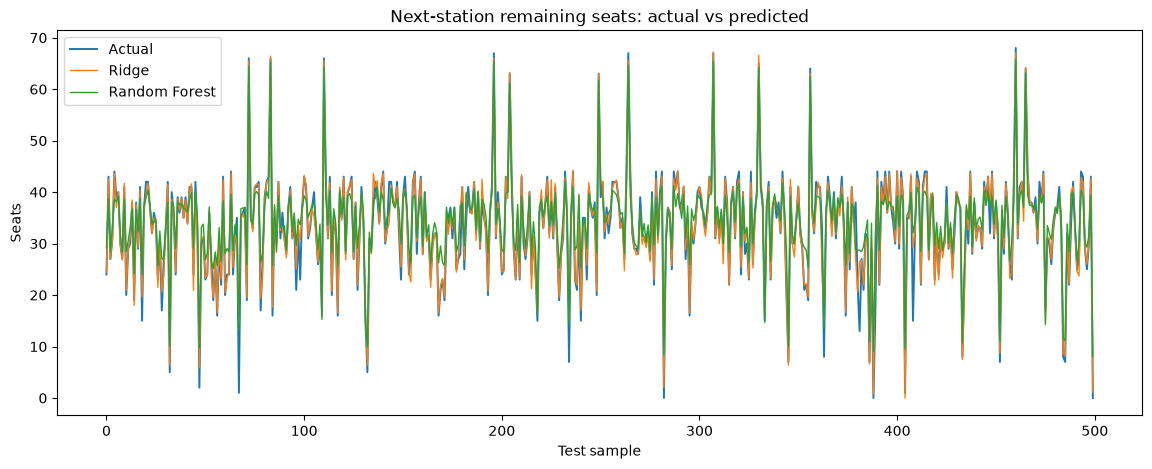

In [6]:
predictions = pd.read_csv(MODEL_DIR / 'predictions.csv', parse_dates=['observed_at'])
sample = predictions.tail(500).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample['arrival_remaining_seats'], label='Actual', linewidth=1.4)
ax.plot(sample['ridge_prediction'], label='Ridge', linewidth=1)
ax.plot(sample['random_forest_prediction'], label='Random Forest', linewidth=1)
ax.set(title='Next-station remaining seats: actual vs predicted', xlabel='Test sample', ylabel='Seats')
ax.legend()
plt.show()

## 6. `.pkl` 모델 불러오기

두 파일 모두 전처리와 회귀 모델이 결합된 scikit-learn `Pipeline`


In [7]:
with (MODEL_DIR / 'ridge_model.pkl').open('rb') as file:
    ridge_model = pickle.load(file)
with (MODEL_DIR / 'random_forest_model.pkl').open('rb') as file:
    random_forest_model = pickle.load(file)

print(ridge_model)
print(random_forest_model)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['remaining_seats',
                                                   'station_seq',
                                                   'next_station_seq',
                                                   'stations_ahead',
                                                   'recent_seat_change',
                                                   'minutes_since_previous_station',
                                                   'hour_sin', 'hour_cos',
                                                   

## 7. 모델을 최신 데이터로 다시 학습하기

아래 셀의 주석을 해제하면 `analyze_and_train.py`를 실행해 `.joblib`, `.pkl`, 평가 보고서와 예측 파일을 모두 갱신합니다.

In [8]:
# %run analyze_and_train.py